In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv("../data/appointments.csv")

# Show basic info
df.info()

# Preview first few rows
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
# Clean column names: lowercase and replace dashes with underscores
df.columns = df.columns.str.lower().str.replace("-", "_").str.strip()

# Show the updated column names
df.columns


Index(['patientid', 'appointmentid', 'gender', 'scheduledday',
       'appointmentday', 'age', 'neighbourhood', 'scholarship', 'hipertension',
       'diabetes', 'alcoholism', 'handcap', 'sms_received', 'no_show'],
      dtype='object')

In [4]:
df['no_show'].value_counts()

no_show
No     88208
Yes    22319
Name: count, dtype: int64

In [5]:
# Create a new binary column: 1 = no-show, 0 = showed up
df['no_show_binary'] = df['no_show'].map({'No': 0, 'Yes': 1})


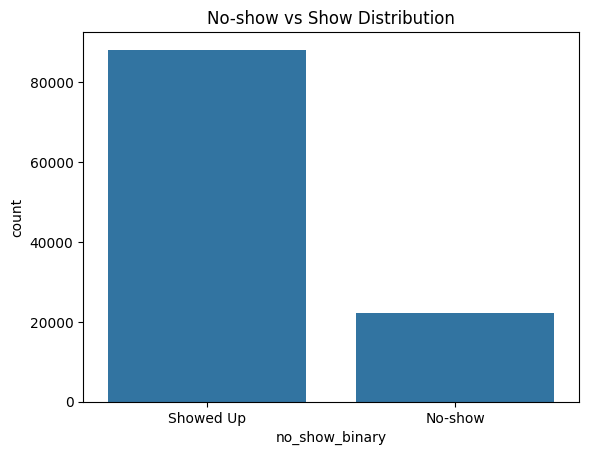

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='no_show_binary', data=df)
plt.title("No-show vs Show Distribution")
plt.xticks([0, 1], ["Showed Up", "No-show"])
plt.show()


In [8]:
df.isnull().sum()

patientid         0
appointmentid     0
gender            0
scheduledday      0
appointmentday    0
age               0
neighbourhood     0
scholarship       0
hipertension      0
diabetes          0
alcoholism        0
handcap           0
sms_received      0
no_show           0
no_show_binary    0
dtype: int64

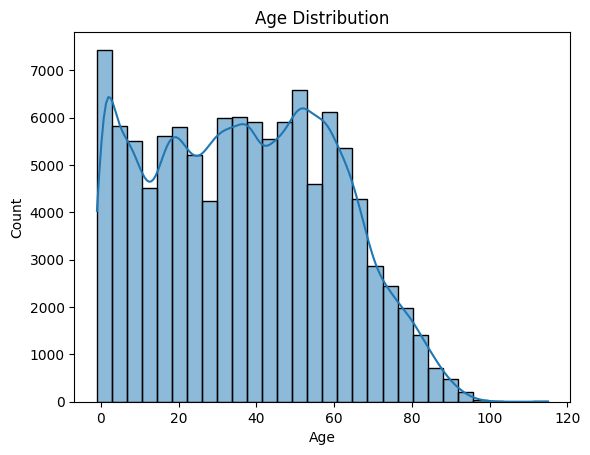

,patientid,appointmentid,gender,scheduledday,appointmentday,age,neighbourhood,scholarship,hipertension,diabetes,alcoholism,handcap,sms_received,no_show,no_show_binary
99832,4.659432e+14,5775010,F,2016-06-06T08:58:13Z,2016-06-06T00:00:00Z,-1,ROMÃO,0,0,0,0,0,0,No,0


In [9]:
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

# Check for negatives or very high ages
df[df['age'] < 0]

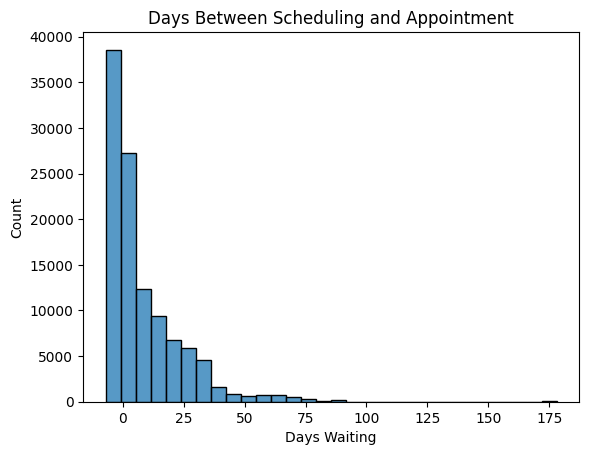

In [10]:
# Convert to datetime
df['scheduledday'] = pd.to_datetime(df['scheduledday'])
df['appointmentday'] = pd.to_datetime(df['appointmentday'])

# Create a new feature
df['days_waiting'] = (df['appointmentday'] - df['scheduledday']).dt.days

# Plot it
sns.histplot(df['days_waiting'], bins=30)
plt.title("Days Between Scheduling and Appointment")
plt.xlabel("Days Waiting")
plt.show()


In [20]:
def show_no_show_rate_by(column):
    return (df.groupby(column)['no_show_binary'].mean() * 100).round(1).astype(str) + "%"

show_no_show_rate_by('gender')

gender
F    20.3%
M    20.0%
Name: no_show_binary, dtype: object

In [21]:
show_no_show_rate_by('sms_received')

sms_received
0    16.7%
1    27.6%
Name: no_show_binary, dtype: object

In [22]:
show_no_show_rate_by('scholarship')

scholarship
0    19.8%
1    23.7%
Name: no_show_binary, dtype: object

In [23]:
df = df[df['age'] >= 0]

In [24]:
features = [
    'age',
    'scholarship',
    'hipertension',
    'diabetes',
    'alcoholism',
    'handcap',
    'sms_received',
    'days_waiting'
]

In [26]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df['no_show_binary']

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Train model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

# Predict
y_pred = logreg.predict(X_test)

# Evaluate
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[17556   159]
 [ 4314    77]]
              precision    recall  f1-score   support

           0       0.80      0.99      0.89     17715
           1       0.33      0.02      0.03      4391

    accuracy                           0.80     22106
   macro avg       0.56      0.50      0.46     22106
weighted avg       0.71      0.80      0.72     22106



In [28]:
coeffs = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logreg.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)

coeffs

,Feature,Coefficient
6,sms_received,0.373171
1,scholarship,0.242645
4,alcoholism,0.169554
3,diabetes,0.107672
5,handcap,0.066767
2,hipertension,-0.028649
7,days_waiting,0.023090
0,age,-0.007630


In [29]:
logreg_bal = LogisticRegression(class_weight='balanced', max_iter=1000)
logreg_bal.fit(X_train, y_train)
y_pred_bal = logreg_bal.predict(X_test)

print(confusion_matrix(y_test, y_pred_bal))
print(classification_report(y_test, y_pred_bal))


[[12264  5451]
 [ 1967  2424]]
              precision    recall  f1-score   support

           0       0.86      0.69      0.77     17715
           1       0.31      0.55      0.40      4391

    accuracy                           0.66     22106
   macro avg       0.58      0.62      0.58     22106
weighted avg       0.75      0.66      0.69     22106



In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


[[12951  4764]
 [ 2256  2135]]
              precision    recall  f1-score   support

           0       0.85      0.73      0.79     17715
           1       0.31      0.49      0.38      4391

    accuracy                           0.68     22106
   macro avg       0.58      0.61      0.58     22106
weighted avg       0.74      0.68      0.71     22106



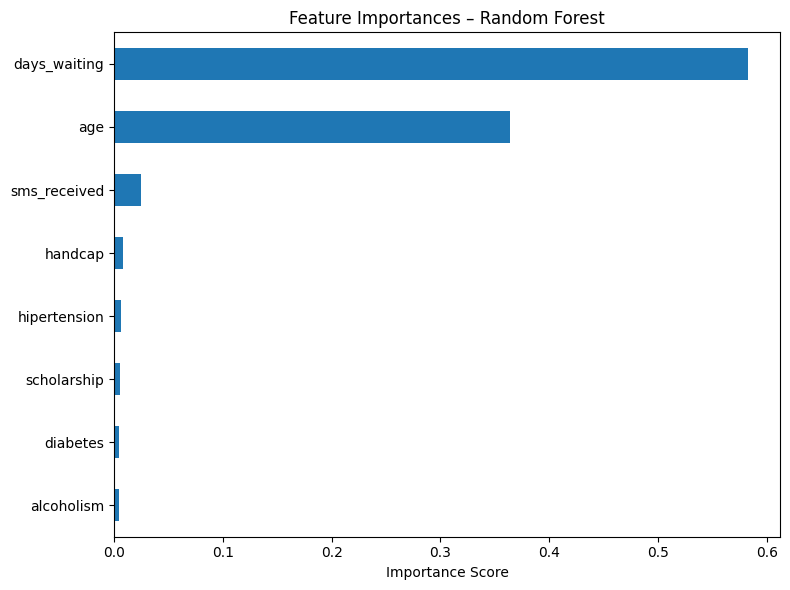

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

# Plot
plt.figure(figsize=(8,6))
importances.plot(kind='barh')
plt.title("Feature Importances – Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


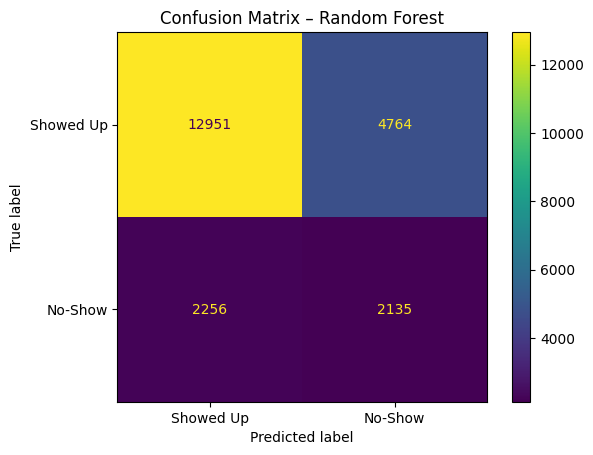

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

# Plot and save confusion matrix
disp = ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, display_labels=["Showed Up", "No-Show"])
plt.title("Confusion Matrix – Random Forest")
plt.savefig("../images/confusion_matrix_rf.png", bbox_inches="tight")
plt.show()

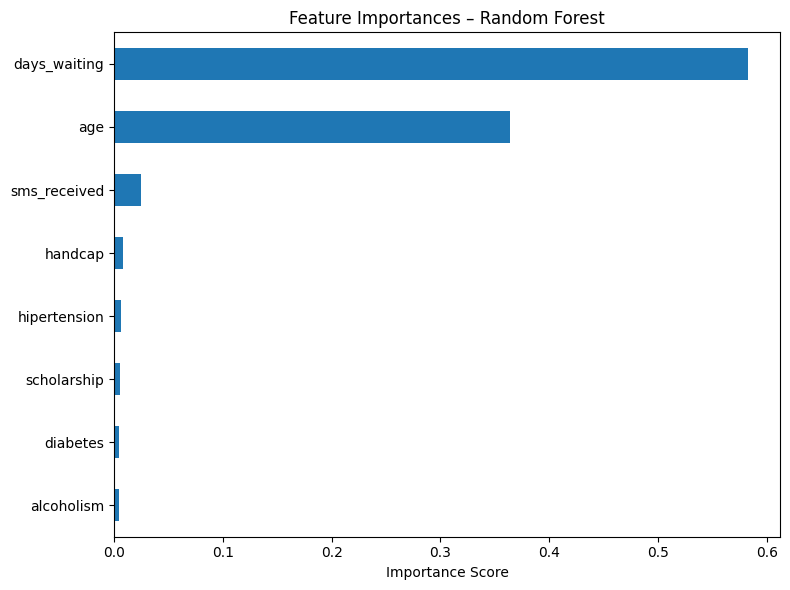

In [33]:
plt.figure(figsize=(8,6))
importances.plot(kind='barh')
plt.title("Feature Importances – Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("../images/feature_importances_rf.png", bbox_inches="tight")
plt.show()